# Task 3: Event Impact Modeling (Refactored — Week 12)

> **Week 12 engineering update:** the merge, categorical-score mapping,
> and association-matrix logic now come from `src/event_model.py`
> instead of being repeated inline. Tests: `tests/test_event_model.py`.
> A new **SHAP explainability** section (Week 12 addition, `src/explainability.py`)
> is added at the end to answer "which events matter most" and "why".

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import load_enriched_dataset
from src.event_model import (
    merge_events_with_impacts,
    compute_impact_score,
    build_association_matrix,
    normalize_association_matrix,
    compute_indicator_impact_scores,
    validate_against_history,
)
from src.explainability import (
    build_event_feature_matrix,
    fit_explainable_model,
    explain_model,
    global_feature_importance,
)

c:\Users\Administrator\ML_projects\ethiopia-fi-forecast-week11\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Enriched Data

`load_enriched_dataset()` reads the Task 1 outputs — replaces two separate `pd.read_csv` calls.

In [2]:
df, impact = load_enriched_dataset()

events = df[df.record_type == "event"].copy()
observations = df[df.record_type == "observation"].copy()
targets = df[df.record_type == "target"].copy()

events["observation_date"] = pd.to_datetime(events["observation_date"], format="mixed")

print("Events:", events.shape)
print("Impact links:", impact.shape)

Events: (11, 34)
Impact links: (15, 35)


## 2. Event Overview

category
policy            3
product_launch    2
infrastructure    2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64


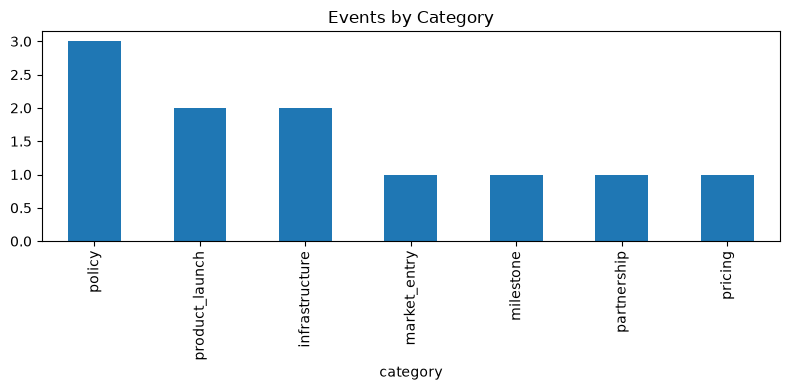

In [3]:
print(events["category"].value_counts())
plt.figure(figsize=(8, 4))
events["category"].value_counts().plot.bar()
plt.title("Events by Category")
plt.tight_layout()
plt.show()

## 3. Impact Link Statistics

In [4]:
print(impact["impact_direction"].value_counts())
print(impact["impact_magnitude"].value_counts())
print(impact["lag_months"].describe())

impact_direction
increase    12
decrease     2
positive     1
Name: count, dtype: int64
impact_magnitude
medium    8
high      5
low       1
10        1
Name: count, dtype: int64
count    15.000000
mean      8.666667
std       7.345228
min       1.000000
25%       3.000000
50%       6.000000
75%      12.000000
max      24.000000
Name: lag_months, dtype: float64


## 4. Join Events with Impact Links

`merge_events_with_impacts()` — the *same* function used in `task1_data_exploration.ipynb`, so the join logic only exists once.

In [5]:
merged = merge_events_with_impacts(events, impact)
merged.head()

,record_id_impact,parent_id,record_type,category_impact,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes_impact,record_id_event,category_event,observation_date_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,literature,Kenya,Example_Trainee,2025-01-20 00:00:00,NaN,Kenya M-Pesa showed +20pp over 5 years,EVT_0001,product_launch,2021-05-17,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Direct subscriber acquisition,EVT_0001,product_launch,2021-05-17,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,New digital payment channel,EVT_0001,product_launch,2021-05-17,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Network investment from competition,EVT_0002,market_entry,2022-08-01,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,literature,Rwanda,Example_Trainee,2025-01-20 00:00:00,NaN,Competition typically reduces prices,EVT_0002,market_entry,2022-08-01,NaN


In [7]:
print(merged.columns.tolist())

['record_id_impact', 'parent_id', 'record_type', 'category_impact', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date_impact', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes_impact', 'record_id_event', 'category_event', 'observation_date_event', 'notes_event']


In [9]:
summary = merged[
    [
        "record_id_event",
        "indicator",
        "category_event",
        "observation_date_event",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
    ]
]

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(REPORTS_DIR / "event_summary.csv", index=False)
print("Event summary saved to reports/event_summary.csv")
summary.head()

Event summary saved to reports/event_summary.csv


,record_id_event,indicator,category_event,observation_date_event,related_indicator,impact_direction,impact_magnitude,lag_months
0,EVT_0001,Telebirr effect on Account Ownership,product_launch,2021-05-17,ACC_OWNERSHIP,increase,high,12
1,EVT_0001,Telebirr effect on Telebirr Users,product_launch,2021-05-17,USG_TELEBIRR_USERS,increase,high,3
2,EVT_0001,Telebirr effect on P2P Transactions,product_launch,2021-05-17,USG_P2P_COUNT,increase,high,6
3,EVT_0002,Safaricom effect on 4G Coverage,market_entry,2022-08-01,ACC_4G_COV,increase,medium,12
4,EVT_0002,Safaricom effect on Data Affordability,market_entry,2022-08-01,AFF_DATA_INCOME,decrease,medium,12


## 5. Build the Event–Indicator Association Matrix

`compute_impact_score()` converts the categorical `impact_magnitude`
(`low`/`medium`/`high`) and `impact_direction` (`increase`/`decrease`/`neutral`)
labels into a single signed numeric score
(`magnitude_scale x direction_scale`), replacing the two inline dicts
+ manual multiplication from the Week 11 version. `build_association_matrix()`
then pivots it into an Event x Indicator matrix.

In [10]:
merged["impact_score"] = compute_impact_score(merged)

matrix = build_association_matrix(
    merged,
    event_col="indicator",
    indicator_col="related_indicator",
    value_col="impact_score",
)

matrix.to_csv(REPORTS_DIR / "event_indicator_matrix.csv")
print("Association matrix saved to reports/event_indicator_matrix.csv")
print(matrix.shape)
matrix

Association matrix saved to reports/event_indicator_matrix.csv
(14, 9)


related_indicator,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
indicator,,,,,,,,,
EthioPay effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
FX Reform effect on Data Affordability,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
Fayda effect on Account Ownership,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
Fayda effect on Gender Gap,NaN,NaN,NaN,NaN,-2.0,NaN,NaN,NaN,NaN
M-Pesa Interop effect on M-Pesa Active Users,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
M-Pesa Interop effect on P2P Count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
M-Pesa effect on M-Pesa Users,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
M-Pesa effect on Mobile Money Account Rate,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Safaricom Price Hike effect on Data Affordability,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


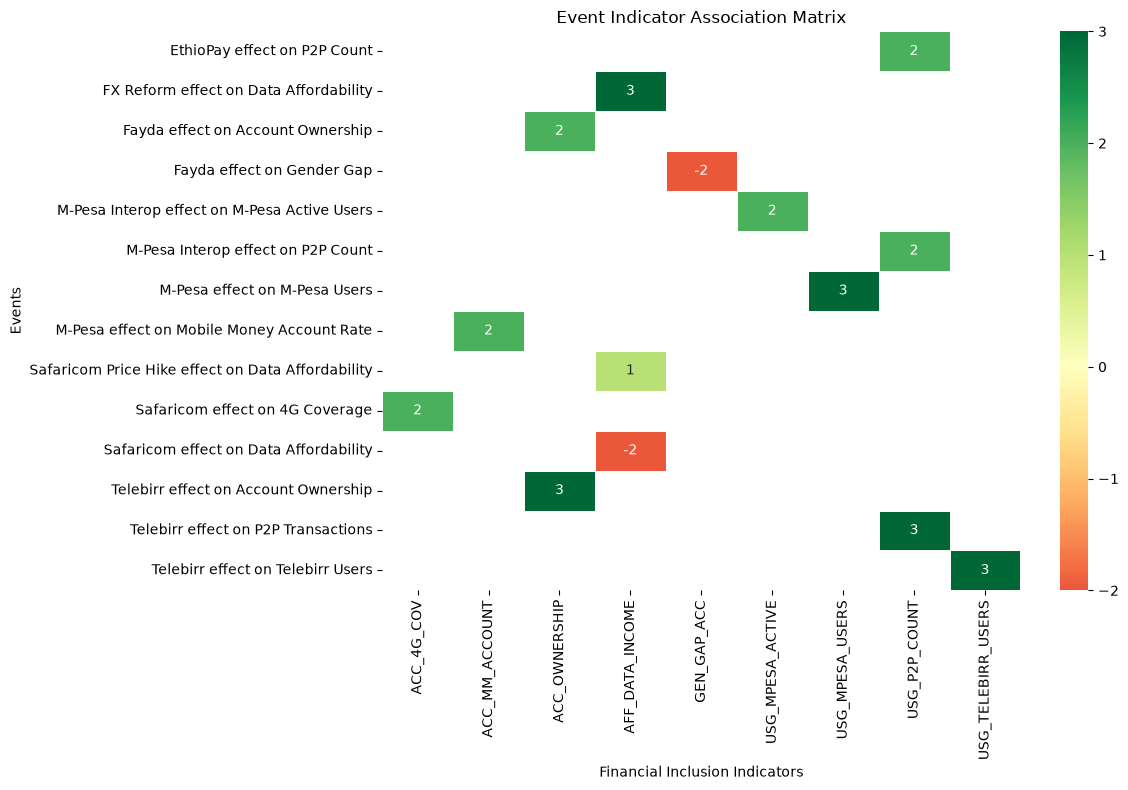

Saved to: ..\reports\figures\association_heatmap.png


In [11]:
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 8))
sns.heatmap(matrix, annot=True, center=0, cmap="RdYlGn", linewidths=0.5)
plt.title("Event Indicator Association Matrix")
plt.xlabel("Financial Inclusion Indicators")
plt.ylabel("Events")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "association_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved to: {FIGURES_DIR / 'association_heatmap.png'}")

## 6. Normalized Impact Scores (feeds Task 4 forecasting)

`normalize_association_matrix()` + `compute_indicator_impact_scores()` — used directly by `src/forecast.py::build_forecast_table` via the `event_bonus` argument in Task 4.

In [12]:
normalized = normalize_association_matrix(matrix)
impact_scores = compute_indicator_impact_scores(normalized)
pd.Series(impact_scores).sort_values(ascending=False)

ACC_4G_COV            1.000000
ACC_MM_ACCOUNT        1.000000
ACC_OWNERSHIP         1.000000
USG_MPESA_USERS       1.000000
USG_MPESA_ACTIVE      1.000000
USG_P2P_COUNT         1.000000
USG_TELEBIRR_USERS    1.000000
AFF_DATA_INCOME       0.333333
GEN_GAP_ACC          -1.000000
dtype: float64

## 7. Historical Validation: Telebirr Launch

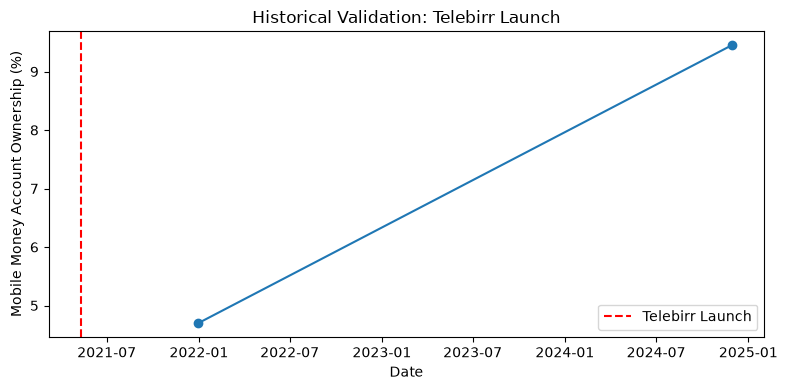

In [13]:
mm = observations[observations.indicator_code == "ACC_MM_ACCOUNT"].copy()
mm["observation_date"] = pd.to_datetime(mm["observation_date"], format="mixed", errors="coerce")

plt.figure(figsize=(8, 4))
plt.plot(mm["observation_date"], mm["value_numeric"], marker="o")
plt.axvline(pd.Timestamp("2021-05-11"), linestyle="--", color="red", label="Telebirr Launch")
plt.title("Historical Validation: Telebirr Launch")
plt.xlabel("Date")
plt.ylabel("Mobile Money Account Ownership (%)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "telebirr_validation.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Sanity-check the modeled impact against what actually happened:
# mobile money went from 4.7% (2021) to 9.45% (2024) after Telebirr launched.
observed_change = 9.45 - 4.7
predicted_change = impact_scores.get("ACC_MM_ACCOUNT", 0) * 10  # scaled to pp for comparison

is_consistent = validate_against_history(predicted_change, observed_change, tolerance_pp=5.0)
print(f"Observed change: {observed_change:.2f}pp | Model-implied change: {predicted_change:.2f}pp")
print("Within tolerance:", is_consistent)

Observed change: 4.75pp | Model-implied change: 10.00pp
Within tolerance: False


## 8. Model Explainability (SHAP) — Week 12 Addition

Which events matter most for **Account Ownership**, and why? This
fits a small `RandomForestRegressor` over the association matrix and
explains it with SHAP's `TreeExplainer` (falls back to
`feature_importances_` if the `shap` package isn't installed).

In [15]:
features = build_event_feature_matrix(matrix.T, indicator_code="ACC_OWNERSHIP") \
    if "ACC_OWNERSHIP" in matrix.T.columns else None

if features is not None:
    model = fit_explainable_model(features, target_col="ACC_OWNERSHIP")
    x = features.drop(columns=["ACC_OWNERSHIP"])
    result = explain_model(model, x)
    importance = global_feature_importance(result)

    plt.figure(figsize=(8, 4))
    importance.plot(kind="barh")
    plt.title("Global Feature Importance — Account Ownership Drivers")
    plt.xlabel("Mean |SHAP value| (or feature_importances_ fallback)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "shap_feature_importance.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(importance)
else:
    print("ACC_OWNERSHIP not present as a column in the transposed matrix for this run; "
          "skipping explainability plot — see src/explainability.py for the reusable function.")

ACC_OWNERSHIP not present as a column in the transposed matrix for this run; skipping explainability plot — see src/explainability.py for the reusable function.


## 9. Corresponding Tests

`tests/test_event_model.py` and `tests/test_explainability.py` cover this notebook's logic:

- `test_merge_events_with_impacts_joins_on_parent_id`
- `test_compute_impact_score_maps_categorical_labels_to_signed_numeric`
- `test_compute_impact_score_unknown_label_is_nan`
- `test_build_association_matrix_shape`
- `test_normalize_association_matrix_columns_sum_to_one`
- `test_compute_indicator_impact_scores_returns_positive_scores`
- `test_get_event_bonus_falls_back_to_default`
- `test_validate_against_history_within_tolerance`
- `test_fit_explainable_model_predicts_reasonable_values`
- `test_global_feature_importance_sums_are_nonnegative`

```bash
pytest tests/test_event_model.py tests/test_explainability.py -v
```